In [1]:
# Step 1: Problem Statement
# "Analyze retail sales data and identify opportunities to increase revenue and profit."
import pandas as pd
df_original = pd.read_csv('amazon_sales.csv')
df = df_original.copy()

In [2]:
# Step 2: Data Cleaning
df.head()   # shows first 5 rows
df.info()   # summary of columns and data types
df.describe()  # statistical summary (For numeric data only )

df.isnull().sum() # Missing values Before
missing_percentage = (2 / 1465) * 100
print(missing_percentage)
df = df.dropna(subset=['rating_count'])
df.isnull().sum() # Missing values After

df.duplicated().sum() # Duplicates 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

np.int64(0)

In [3]:
print(df['discounted_price'].dtype)
print(df['discounted_price'].head(10))
df['discounted_price'].unique()[:10]
# This code is idempotent, meaning you can run it multiple times without causing errors.
df['discounted_price_cleaned'] = pd.to_numeric(
df['discounted_price']
.str.replace('₹', '', regex=False)
.str.replace(',', '', regex=False),
errors='coerce'
)
print(df['discounted_price_cleaned'].dtype)
print(df['discounted_price_cleaned'].head(10))
df.info()
# Interpretation Rule (Very Important)
# Missing      Action
# < 1%         Ignore or drop
# 1%–5%        Simple imputation
# 5%–20%       Careful imputation + analysis
# > 20%         Serious issue
# Regex - Regular Expression is working character by character, not understanding numbers.
# r'[^\d.-]' -  \d → digits . → dot - → must be added manually ^ → NOT 
# NaN stands for Not a Number

object
0       ₹399
1       ₹199
2       ₹199
3       ₹329
4       ₹154
5       ₹149
6    ₹176.63
7       ₹229
8       ₹499
9       ₹199
Name: discounted_price, dtype: object
float64
0    399.00
1    199.00
2    199.00
3    329.00
4    154.00
5    149.00
6    176.63
7    229.00
8    499.00
9    199.00
Name: discounted_price_cleaned, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_id                1463 non-null   object 
 1   product_name              1463 non-null   object 
 2   category                  1463 non-null   object 
 3   discounted_price          1463 non-null   object 
 4   actual_price              1463 non-null   object 
 5   discount_percentage       1463 non-null   object 
 6   rating                    1463 non-null   object 
 7   rating_count              1463 non-null   object

In [4]:
print(df['actual_price'].dtype)
print(df['actual_price'].head(10))
df['actual_price'].unique()[:10]

df['actual_price_cleaned'] = pd.to_numeric(
df['actual_price']
.str.replace('₹', '', regex=False)
.str.replace(',', '', regex=False),
errors='coerce'
)
print(df['actual_price_cleaned'].dtype)
print(df['actual_price_cleaned'].head(10))
df.info()


object
0    ₹1,099
1      ₹349
2    ₹1,899
3      ₹699
4      ₹399
5    ₹1,000
6      ₹499
7      ₹299
8      ₹999
9      ₹299
Name: actual_price, dtype: object
float64
0    1099.0
1     349.0
2    1899.0
3     699.0
4     399.0
5    1000.0
6     499.0
7     299.0
8     999.0
9     299.0
Name: actual_price_cleaned, dtype: float64
<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_id                1463 non-null   object 
 1   product_name              1463 non-null   object 
 2   category                  1463 non-null   object 
 3   discounted_price          1463 non-null   object 
 4   actual_price              1463 non-null   object 
 5   discount_percentage       1463 non-null   object 
 6   rating                    1463 non-null   object 
 7   rating_count              1463 non-null   object 
 8   about_produ

In [5]:
df[['actual_price', 'actual_price_cleaned']].head()
df['actual_price_cleaned'].unique()[:10]
df['actual_price'] = df['actual_price_cleaned']
df.drop(columns='actual_price_cleaned', inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_id                1463 non-null   object 
 1   product_name              1463 non-null   object 
 2   category                  1463 non-null   object 
 3   discounted_price          1463 non-null   object 
 4   actual_price              1463 non-null   float64
 5   discount_percentage       1463 non-null   object 
 6   rating                    1463 non-null   object 
 7   rating_count              1463 non-null   object 
 8   about_product             1463 non-null   object 
 9   user_id                   1463 non-null   object 
 10  user_name                 1463 non-null   object 
 11  review_id                 1463 non-null   object 
 12  review_title              1463 non-null   object 
 13  review_content            1463 non-null   object 
 14  img_link     

In [7]:
print(df['discount_percentage'].dtype)
print(df['discount_percentage'].head(10))
df['discount_percentage'].unique()[:10]


object
0    64%
1    43%
2    90%
3    53%
4    61%
5    85%
6    65%
7    23%
8    50%
9    33%
Name: discount_percentage, dtype: object


array(['64%', '43%', '90%', '53%', '61%', '85%', '65%', '23%', '50%',
       '33%'], dtype=object)

In [8]:
df['discount_percentage_cleaned'] = pd.to_numeric(
df['discount_percentage']
.str.replace('%', '', regex=False),
    errors='coerce'
)
print(df['discount_percentage_cleaned'].dtype)
print(df['discount_percentage_cleaned'].head(10))
print(df['discount_percentage_cleaned'].unique()[:10])

df.info()


int64
0    64
1    43
2    90
3    53
4    61
5    85
6    65
7    23
8    50
9    33
Name: discount_percentage_cleaned, dtype: int64
[64 43 90 53 61 85 65 23 50 33]
<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   product_id                   1463 non-null   object 
 1   product_name                 1463 non-null   object 
 2   category                     1463 non-null   object 
 3   discounted_price             1463 non-null   object 
 4   actual_price                 1463 non-null   float64
 5   discount_percentage          1463 non-null   object 
 6   rating                       1463 non-null   object 
 7   rating_count                 1463 non-null   object 
 8   about_product                1463 non-null   object 
 9   user_id                      1463 non-null   object 
 10  user_name                    14

In [9]:
df[['discount_percentage', 'discount_percentage_cleaned']].head()
df['discount_percentage_cleaned'].unique()[:10]
df['discount_percentage'] = df['discount_percentage_cleaned']
df.drop(columns='discount_percentage_cleaned', inplace=True)

In [10]:
df['discount_percentage_numeric'] = df['discount_percentage'] 

df['discount_percentage_display'] = (
    df['discount_percentage_numeric']
    .round(1)
    .astype(str) + '%'
)

In [11]:
print(df['rating'].dtype)
print(df['rating'].head(10))
df['rating'].unique()[:10]

df['rating_cleaned'] = pd.to_numeric(
    df['rating'],
    errors='coerce'
)
print(df['rating_cleaned'].dtype)
print(df['rating_cleaned'].head(10))
df['rating_cleaned'].unique()[:10]
    

object
0    4.2
1    4.0
2    3.9
3    4.2
4    4.2
5    3.9
6    4.1
7    4.3
8    4.2
9    4.0
Name: rating, dtype: object
float64
0    4.2
1    4.0
2    3.9
3    4.2
4    4.2
5    3.9
6    4.1
7    4.3
8    4.2
9    4.0
Name: rating_cleaned, dtype: float64


array([4.2, 4. , 3.9, 4.1, 4.3, 4.4, 4.5, 3.7, 3.3, 3.6])

In [12]:
df['rating'] = df['rating_cleaned']
df.drop(columns='rating_cleaned', inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   product_id                   1463 non-null   object 
 1   product_name                 1463 non-null   object 
 2   category                     1463 non-null   object 
 3   discounted_price             1463 non-null   object 
 4   actual_price                 1463 non-null   float64
 5   discount_percentage          1463 non-null   int64  
 6   rating                       1462 non-null   float64
 7   rating_count                 1463 non-null   object 
 8   about_product                1463 non-null   object 
 9   user_id                      1463 non-null   object 
 10  user_name                    1463 non-null   object 
 11  review_id                    1463 non-null   object 
 12  review_title                 1463 non-null   object 
 13  review_content         

In [14]:
print(df['rating_count'].head(10))
df['rating_count'].unique()[:10]

0      24,269
1      43,994
2       7,928
3      94,363
4      16,905
5      24,871
6      15,188
7      30,411
8    1,79,691
9      43,994
Name: rating_count, dtype: object


array(['24,269', '43,994', '7,928', '94,363', '16,905', '24,871',
       '15,188', '30,411', '1,79,691', '13,391'], dtype=object)

In [15]:
df['rating_count_cleaned'] = pd.to_numeric(
    df['rating_count']
    .str.replace(',', '', regex=False),
    errors='coerce'
)
print(df['rating_count_cleaned'].dtype)
print(df['rating_count_cleaned'].head(10))
df['rating_count_cleaned'].unique()[:10]


int64
0     24269
1     43994
2      7928
3     94363
4     16905
5     24871
6     15188
7     30411
8    179691
9     43994
Name: rating_count_cleaned, dtype: int64


array([ 24269,  43994,   7928,  94363,  16905,  24871,  15188,  30411,
       179691,  13391])

In [16]:
df['rating_count'] = df['rating_count_cleaned']
df.drop(columns='rating_count_cleaned', inplace=True)


In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   product_id                   1463 non-null   object 
 1   product_name                 1463 non-null   object 
 2   category                     1463 non-null   object 
 3   discounted_price             1463 non-null   object 
 4   actual_price                 1463 non-null   float64
 5   discount_percentage          1463 non-null   int64  
 6   rating                       1462 non-null   float64
 7   rating_count                 1463 non-null   int64  
 8   about_product                1463 non-null   object 
 9   user_id                      1463 non-null   object 
 10  user_name                    1463 non-null   object 
 11  review_id                    1463 non-null   object 
 12  review_title                 1463 non-null   object 
 13  review_content         

In [18]:
# How to inspect a row that is missing in a column
df['rating'].isnull().sum() #Confirm a row is missing
df[df['rating'].isnull()] #Find the row
#Inspect the original value OR
# If you still have the original column before cleaning, check:
df.loc[df['rating'].isnull(), 'rating'] 
df['rating'].unique()

array([4.2, 4. , 3.9, 4.1, 4.3, 4.4, 4.5, 3.7, 3.3, 3.6, 3.4, 3.8, 3.5,
       4.6, 3.2, 5. , 4.7, 3. , 2.8, 3.1, 4.8, 2.3, nan, 2. , 2.6, 2.9])

In [38]:
df['category'].value_counts() # No of products in each category
#df['category'].value_counts().reset_index()

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                                          231
Electronics|WearableTechnology|SmartWatches                                                                                 76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                                                        68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                                               63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                                                52
                                                                                                                          ... 
Electronics|Cameras&Photography|Accessories|Batteries&Chargers|BatteryChargers                                               1
Computers&Accessories|NetworkingDevices|DataCards&Dongles                                             

In [39]:
df.groupby('category')['rating'].mean() # Avg rating by category

category
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers                                                    3.800000
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters                                                   4.150000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets                                           3.500000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                                        3.600000
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers                                           4.050000
                                                                                                                            ...   
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens        4.250000
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSu

In [40]:
# Avg discount by Category
df.groupby('category')['discount_percentage_numeric'].mean()


category
Car&Motorbike|CarAccessories|InteriorAccessories|AirPurifiers&Ionizers                                                    42.0
Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters                                                   78.5
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets                                           35.0
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones                                        56.5
Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers                                           46.5
                                                                                                                          ... 
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|GelInkRollerballPens         0.0
OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|LiquidIn

In [41]:
# Phase 2: Univariate Analysis
df['actual_price'].describe()

# The median depends only on position, so it is resistant to outliers.
# Quartiles are used to understand how data is spread out. It help you: See where most values lie identify 
# low, middle, and high parts of data. Think of quartiles as a tool for breaking data into positions. 
# It tells whether the data is balanced or skewed, If most values are in the lower quartiles, the data is not
# evenly spread. Quartiles show whether the mean represents the data well or is misleading
# Standard deviation tells you how spread out your data is from the mean (average). In simple words:
# It measures the average distance of data values from the mean.

count      1463.000000
mean       5451.068544
std       10881.018448
min          39.000000
25%         800.000000
50%        1690.000000
75%        4312.500000
max      139900.000000
Name: actual_price, dtype: float64

In [ ]:
Business Insight:
The average actual price is ₹5,451, while the median price is ₹1,690. The substantial difference between the 
mean and median indicates a right-skewed distribution, suggesting that a small number of high-priced products
significantly increase the average price. Most products are concentrated in the lower price range.

The average product price is ₹5,451, the median price is only ₹1,690, indicating that most products are 
concentrated in the lower price range while a few premium products drive up the average.

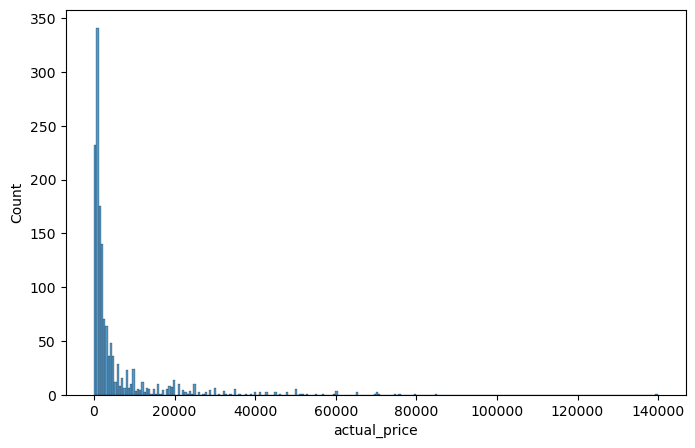

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['actual_price'], bins=250)
plt.show()
# showing many cheap products and a few expensive ones.

In [49]:
#Run this if df not defined error happens
#import pandas as pd
#df = pd.read_csv("amazon_sales.csv")

In [44]:
df['rating'].describe()

count    1462.000000
mean        4.096717
std         0.289497
min         2.000000
25%         4.000000
50%         4.100000
75%         4.300000
max         5.000000
Name: rating, dtype: float64

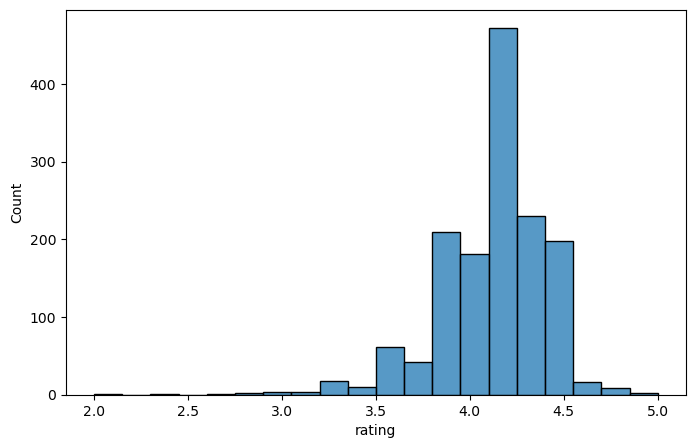

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20)
plt.show()

In [46]:
df['discount_percentage_numeric'].describe()

count    1463.000000
mean       47.650718
std        21.622373
min         0.000000
25%        32.000000
50%        50.000000
75%        63.000000
max        94.000000
Name: discount_percentage_numeric, dtype: float64

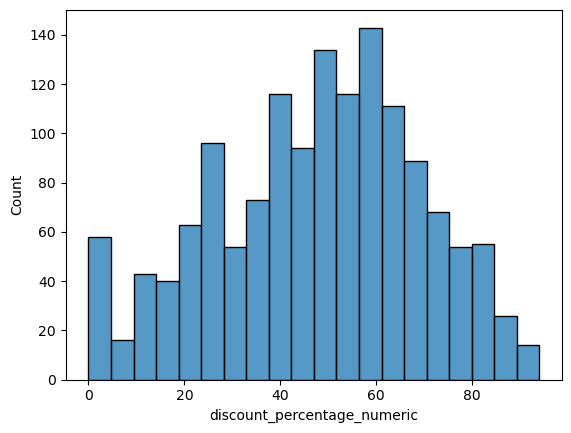

In [47]:
sns.histplot(df['discount_percentage_numeric'], bins=20)
plt.show()
# std (21.64): This shows how much the discounts vary. A SD of 21.6% means the discounts are quite spread out 
# from the average, rather than everyone getting the exact same deal.

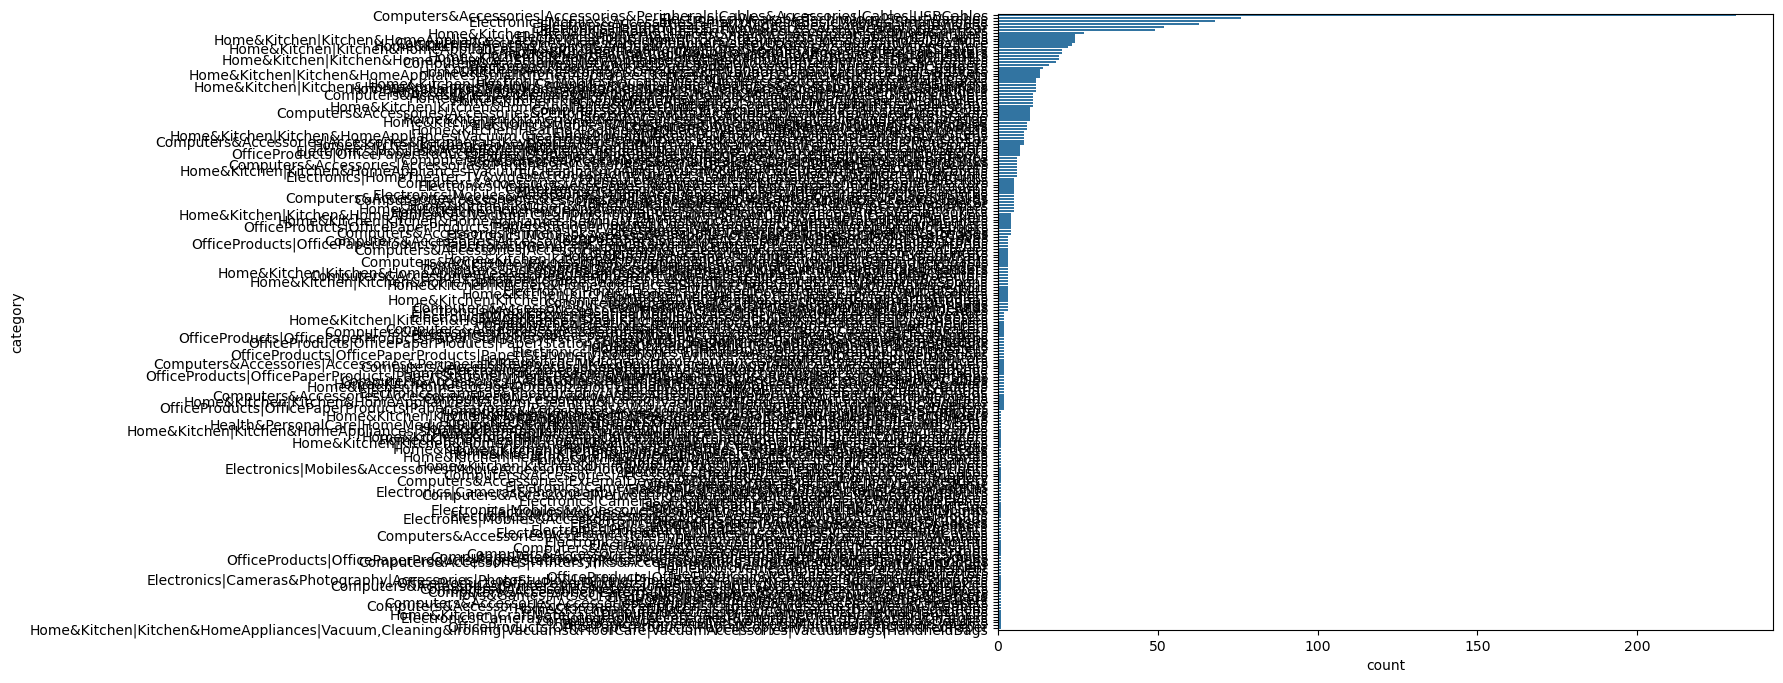

In [48]:
# Phase 3: Categorical Analysis
df['category'].value_counts()
plt.figure(figsize=(10,8))
sns.countplot(
    y='category',
    data=df,
    order=df['category'].value_counts().index
)
plt.show()

In [50]:
# Phase 4: Feature Engineering

df['saving_amount'] = df['actual_price'] - df['discounted_price_cleaned']
df[['actual_price',
    'discounted_price_cleaned',
    'saving_amount']].head()

,actual_price,discounted_price_cleaned,saving_amount
0,1099.0,399.0,700.0
1,349.0,199.0,150.0
2,1899.0,199.0,1700.0
3,699.0,329.0,370.0
4,399.0,154.0,245.0


In [51]:
# Rating Category
df['rating_category'] = pd.cut(
    df['rating'],
    bins=[0,3,4,4.5,5],
    labels=['Low','Average','Good','Excellent']
)
df['rating_category'].value_counts()

rating_category
Good         900
Average      525
Excellent     28
Low            9
Name: count, dtype: int64

In [52]:
# Price Category
df['price_category'] = pd.cut(
    df['actual_price'],
    bins=[0,1000,5000,20000,150000],
    labels=['Budget','Mid-range','Premium','Luxury']
)
df['price_category'].value_counts()

price_category
Mid-range    603
Budget       539
Premium      224
Luxury        97
Name: count, dtype: int64

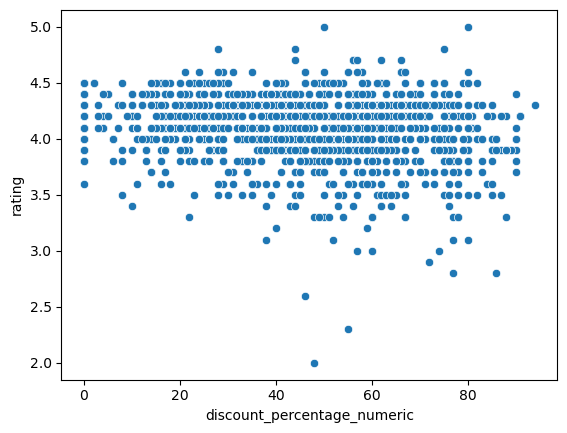

In [53]:
# Phase 5: Bivariate Analysis
# Does a higher discount lead to better ratings?
sns.scatterplot(
    x='discount_percentage_numeric',
    y='rating',
    data=df
)
plt.show()

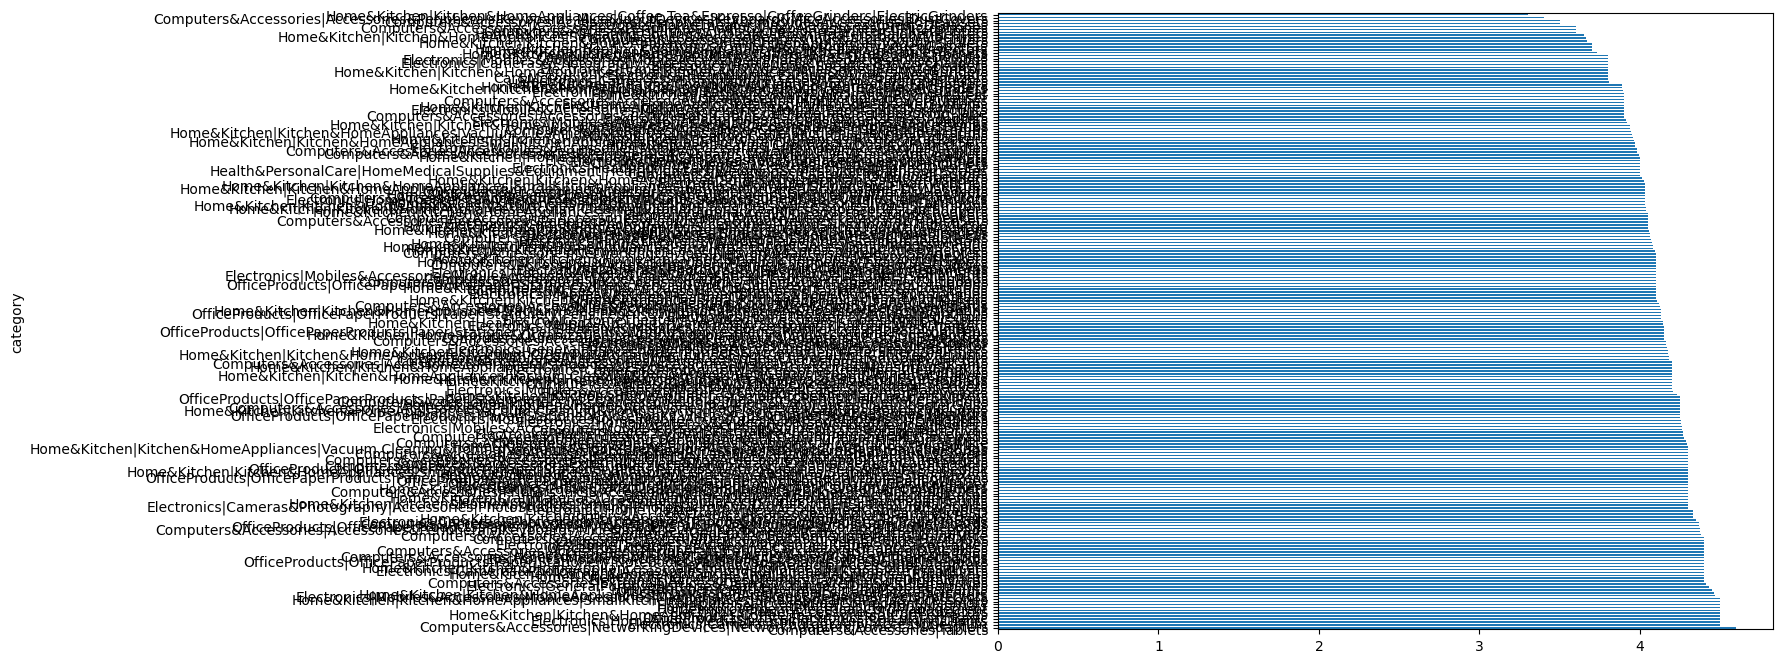

In [54]:
# Category-wise Average Rating
category_rating = (
    df.groupby('category')['rating']
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10,8))
category_rating.plot(kind='barh')
plt.show()

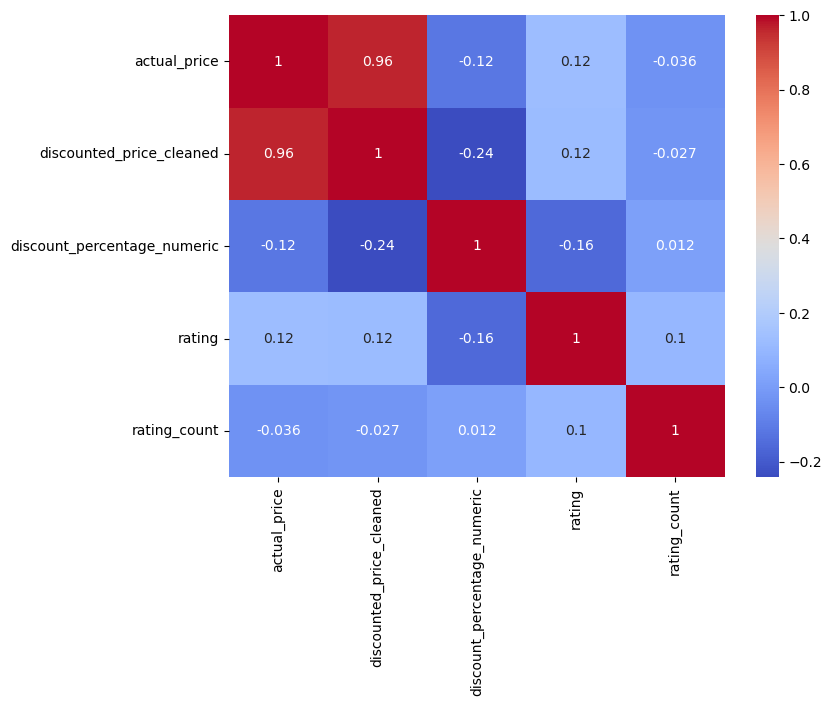

In [55]:
# Phase 6
# Correlation Analysis
numeric_cols = [
    'actual_price',
    'discounted_price_cleaned',
    'discount_percentage_numeric',
    'rating',
    'rating_count',
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [56]:
# Phase 7: Top Products
#Highest-rated products
df[['product_name','rating']]\
.sort_values(by='rating', ascending=False)\
.head(10)

,product_name,rating
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0
1201,"Oratech Coffee Frother electric, milk frother ...",4.8
1299,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",4.8
1145,Swiffer Instant Electric Water Heater Faucet T...,4.8
1223,"FIGMENT Handheld Milk Frother Rechargeable, 3-...",4.7
1226,Zuvexa USB Rechargeable Electric Foam Maker - ...,4.7
459,Spigen EZ Fit Tempered Glass Screen Protector ...,4.7
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,4.7
1275,Multifunctional 2 in 1 Electric Egg Boiling St...,4.7


In [57]:
# Most reviewed products
df[['product_name','rating_count']]\
.sort_values(by='rating_count', ascending=False)\
.head(10)

,product_name,rating_count
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,426972
400,boAt Bassheads 100 in Ear Wired Earphones with...,363713
352,boAt Bassheads 100 in Ear Wired Earphones with...,363713
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,363711
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",313836
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",313836
473,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",313832


In [58]:
# Products with largest discounts
df[['product_name',
    'discount_percentage_numeric']]\
.sort_values(
    by='discount_percentage_numeric',
    ascending=False
)\
.head(10)

,product_name,discount_percentage_numeric
695,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...",94
372,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91
380,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91
368,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91
364,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91
334,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91
602,LAPSTER Spiral Charger Spiral Charger Cable Pr...,90
407,Sounce Spiral Charger Cable Protector Data Cab...,90
557,LAPSTER 12pcs Spiral Cable Protectors for Char...,90
644,Sounce Spiral Charger Cable Protector Data Cab...,90


count      1463.000000
mean       5451.068544
std       10881.018448
min          39.000000
25%         800.000000
50%        1690.000000
75%        4312.500000
max      139900.000000
Name: actual_price, dtype: float64


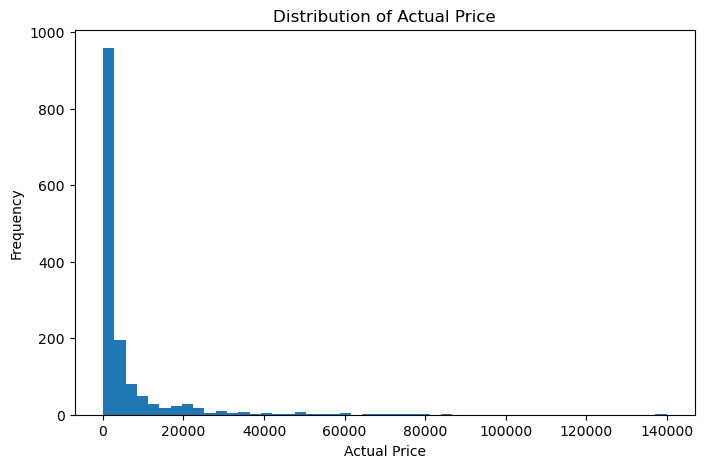

In [59]:
# Phase 8: Outliner Detection
print(df['actual_price'].describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['actual_price'], bins=50)
plt.xlabel('Actual Price')
plt.ylabel('Frequency')
plt.title('Distribution of Actual Price')
plt.show()
# If: Mean >> Median, then the data is positively skewed.
# Right skewed data as long right tail
# High-priced products naturally appear as outliers mathematically, but they are real observations, 
# not mistakes.

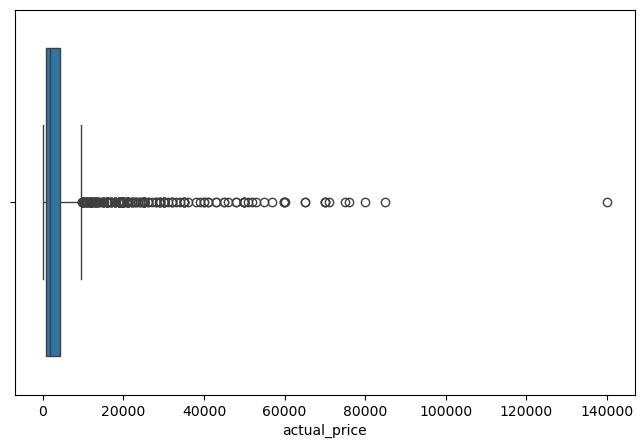

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['actual_price'])
plt.show()
# # If you see a long right tail, the data is right-skewed.

In [60]:
Q1 = df['actual_price'].quantile(0.25)
Q3 = df['actual_price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outliers = df[
    (df['actual_price'] < lower_bound) |
    (df['actual_price'] > upper_bound)
]
pd.set_option('display.max_colwidth', None)

display(outliers[['product_name', 'actual_price']])
print(upper_bound)

# Upper bound is ₹9,581, which means the IQR rule considers anything above ₹9,581 an outlier. In an Amazon 
# dataset, that is far too low because products such as TVs, smartphones, laptops, vacuum cleaners, and 
# water purifiers naturally cost much more. Therefore, those 213 "outliers" are not really outliers—they 
# are just expensive products.

,product_name,actual_price
16,MI 80 cm (32 inches) 5A Series HD Ready Smart Android LED TV L32M7-5AIN (Black),24999.0
19,LG 80 cm (32 inches) HD Ready Smart LED TV 32LM563BPTC (Dark Iron Gray),21990.0
22,Samsung 80 cm (32 Inches) Wondertainment Series HD Ready LED Smart TV UA32T4340BKXXL (Glossy Black),22900.0
24,Acer 80 cm (32 inches) I Series HD Ready Android Smart LED TV AR32AR2841HDFL (Black),19990.0
26,OnePlus 80 cm (32 inches) Y Series HD Ready LED Smart Android TV 32Y1 (Black),19999.0
...,...,...
1416,"Aqua d pure Active Copper 12-L RO+UV Water Filter Purifier for Home, Kitchen Fully Automatic UF+TDS Controller",24999.0
1430,"Mi Robot Vacuum-Mop P, Best-in-class Laser Navigation in 10-20K INR price band, Intelligent mapping, Robotic Floor Cleaner with 2 in 1 Mopping and Vacuum, App Control (WiFi, Alexa,GA), Strong suction",29999.0
1432,"AGARO Royal Stand 1000W Mixer with 5L SS Bowl and 8 Speed Setting, Includes Whisking Cone, Mixing Beater & Dough Hook, and Splash Guard, 2 Years Warranty, (Black), Medium (33554)",11495.0
1437,"Karcher WD3 EU Wet and Dry Vacuum Cleaner, 1000 Watts Powerful Suction, 17 L Capacity, Blower Function, Easy Filter Removal for Home and Garden Cleaning (Yellow/Black)",10999.0


9581.25


In [61]:
outliers[['product_name', 'actual_price']].sort_values(
    by='actual_price',
    ascending=False
)
# Check extreme values i.e highest prices. Ask: Are they valid products? Typing mistakes? Missing decimal 
# points? Luxury products?

,product_name,actual_price
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black),139900.0
255,VU 164 cm (65 inches) The GloLED Series 4K Smart LED Google TV 65GloLED (Grey),85000.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV 55UQ7500PSF (Ceramic Black),79990.0
1354,"LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (Copper, Super Convertible 6-in-1 Cooling, HD Filter with Anti-Virus Protection, 2022 Model, PS-Q19YNZE, White)",75990.0
568,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM, 128GB Storage) with No Cost EMI & Additional Exchange Offers",74999.0
...,...,...
1141,Philips PowerPro FC9352/01 Compact Bagless Vacuum Cleaner (Blue),9995.0
1236,"PHILIPS Air Fryer HD9200/90, uses up to 90% less fat, 1400W, 4.1 Liter, with Rapid Air Technology (Black), Large",9995.0
210,"WZATCO Pixel | Portable LED Projector | Native 720p with Full HD 1080P Support | 2000 Lumens (200 ANSI) | 176"" Large Screen | Projector for Home and Outdoor | Compatible with TV Stick, PC, PS4",9990.0
1091,"Bajaj New Shakti Neo 10L Vertical Storage Water Heater (Geyser 10 Litres) 4 Star BEE Rated Heater For Water Heating with Titanium Armour, Swirl Flow Technology, Glasslined Tank(White), 1 Yr Warranty",9650.0


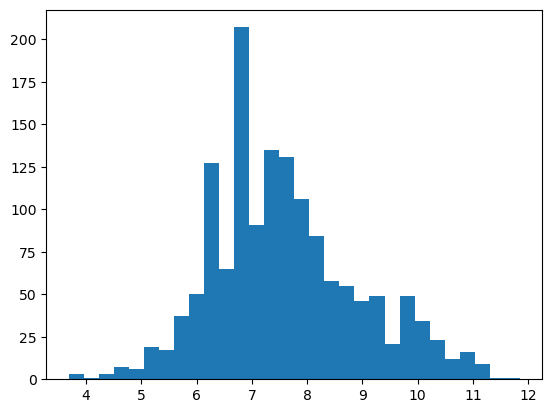

,product_name,actual_price
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black),139900.0
255,VU 164 cm (65 inches) The GloLED Series 4K Smart LED Google TV 65GloLED (Grey),85000.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV 55UQ7500PSF (Ceramic Black),79990.0
1354,"LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (Copper, Super Convertible 6-in-1 Cooling, HD Filter with Anti-Virus Protection, 2022 Model, PS-Q19YNZE, White)",75990.0
568,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM, 128GB Storage) with No Cost EMI & Additional Exchange Offers",74999.0
192,Samsung 138 cm (55 inches) Crystal 4K Neo Series Ultra HD Smart LED TV UA55AUE65AKXXL (Black),70900.0
332,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD LED Smart Android TV L55M6-ES (Grey),69999.0
325,OnePlus 163.8 cm (65 inches) U Series 4K LED Smart Android TV 65U1S (Black),69999.0
276,Samsung 138 cm (55 inches) Crystal 4K Series Ultra HD Smart LED TV UA55AUE60AKLXL (Black),69900.0
108,VU 139 cm (55 inches) The GloLED Series 4K Smart LED Google TV 55GloLED (Grey),65000.0


In [62]:
import numpy as np

df['log_actual_price'] = np.log1p(df['actual_price'])
plt.hist(df['log_actual_price'], bins=30)
plt.show()
df[['product_name', 'actual_price']]\
.sort_values(by='actual_price', ascending=False)\
.head(20)

# If Data is Highly Skewed, Apply Log Transformation, Check the histogram again. A nearly symmetric 
# distribution indicates successful normalization.

In [63]:
print("Skewness before log:",
      df['actual_price'].skew())

print("Skewness after log:",
      df['log_actual_price'].skew())

#Interpretation
#Skewness	Interpretation
#≈ 0	        Symmetric
#0.5 – 1	    Moderately skewed
#> 1	        Highly skewed
#< -1	        Highly left-skewed

Skewness before log: 4.55675045839722
Skewness after log: 0.4675091211973578


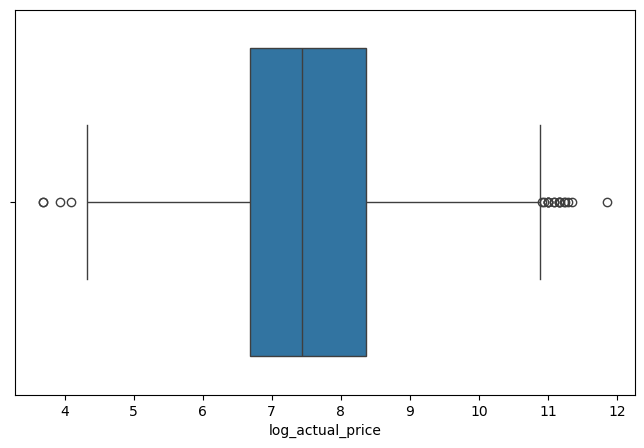

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['log_actual_price'])
plt.show()

In [65]:
Q1 = df['log_actual_price'].quantile(0.25)
Q3 = df['log_actual_price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

log_outliers = df[
    (df['log_actual_price'] < lower_bound) |
    (df['log_actual_price'] > upper_bound)
]

print("Number of outliers after log transformation:", len(log_outliers))
display(log_outliers[['product_name','actual_price']])

# Repeat Outlier Detection on Log Data, This usually produces much more meaningful outliers.

Number of outliers after log transformation: 21


,product_name,actual_price
108,VU 139 cm (55 inches) The GloLED Series 4K Smart LED Google TV 55GloLED (Grey),65000.0
150,VU 138 cm (55 inches) Premium Series 4K Ultra HD Smart IPS LED TV 55UT (Black),65000.0
192,Samsung 138 cm (55 inches) Crystal 4K Neo Series Ultra HD Smart LED TV UA55AUE65AKXXL (Black),70900.0
216,OnePlus 138.7 cm (55 inches) U Series 4K LED Smart Android TV 55U1S (Black),59999.0
232,Sansui 140cm (55 inches) 4K Ultra HD Certified Android LED TV with Dolby Audio & Dolby Vision JSW55ASUHD (Mystique Black),56790.0
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black),139900.0
255,VU 164 cm (65 inches) The GloLED Series 4K Smart LED Google TV 65GloLED (Grey),85000.0
276,Samsung 138 cm (55 inches) Crystal 4K Series Ultra HD Smart LED TV UA55AUE60AKLXL (Black),69900.0
283,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV 55UQ7500PSF (Ceramic Black),79990.0
292,Hisense 126 cm (50 inches) Bezelless Series 4K Ultra HD Smart LED Google TV 50A6H (Black),54990.0


In [66]:
from scipy.stats import zscore

df['z_log_price'] = zscore(df['log_actual_price'])

suspicious = df[
    abs(df['z_log_price']) > 3
]

display(
    suspicious[['product_name',
                'actual_price',
                'z_log_price']]
)

#For your Amazon Sales dataset, the conclusion is:
# All 1463 observations are legitimate. No rows should be deleted. The apparent outliers are a consequence of 
# the large variation between inexpensive and premium products, not data quality issues.**

,product_name,actual_price,z_log_price
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black),139900.0,3.18981


In [67]:

For sales, price, income, and e-commerce datasets, the following workflow is recommend.
# Step 1: Understand the Distribution
df['actual_price'].describe()
If: Mean >> Med, then the data is positively skewed.

# Step 2: Visualize the Data
plt.hist(df['actual_price'], bins=50)
plt.boxplot(df['actual_price'])
If you see a long right tail, the data is right-skewed.

# Step 3: Detect Outliers Using IQR

# Step 4: Never Remove Outliers Immediately
Statistical outlier ≠ bad data.
Always inspect:
outliers[['product_name','actual_price']]
Ask: # Is the value possible? # Is it a typing mistake?
# Step 5: If Data is Highly Skewed, Apply Log Transformation, Check the histogram again.
# A nearly symmetric distribution indicates successful normalization.

# Step 6: Repeat Outlier Detection on Log Data
This usually produces much more meaningful outliers.

# Step 7: Confirm with Z-Scores

# Step 8: Use Domain Knowledge
Ask:
| Impossible value?             | Remove         |
| Data-entry error?             | Correct/Remove |
| Legitimate premium product?   | Keep           |
| Rare but genuine observation? | Keep           |

# Step 9: Decide

### Remove rows only if:
* Recording errors exist.
* Values are impossible.
* Units are inconsistent.

### Otherwise:
Keep the observations.

# Step 10: Use Both Columns
Keep:
### `actual_price` for:
* Business interpretation
* Dashboarding
* Reporting
### `log_actual_price` for:
* Correlation analysis
* Regression
* Machine learning
* Statistical tests

SyntaxError: invalid character '≠' (U+2260) (1255754751.py, line 14)

In [68]:
# Text Analysis
# Review length
df['review_length'] = (
    df['review_content']
    .str.len()
)

# Do highly-rated products have longer reviews?
# Do popular products receive longer reviews?

In [69]:
# Word Count
df['review_word_count'] = (
    df['review_content']
    .str.split()
    .str.len()
)
df[['review_content', 'review_length']].head()


,review_content,review_length
0,"Looks durable Charging is fine tooNo complains,Charging is really fast, good product.,Till now satisfied with the quality.,This is a good product . The charging speed is slower than the original iPhone cable,Good quality, would recommend,https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/81---F1ZgHL._SY88.jpg,Product had worked well till date and was having no issue.Cable is also sturdy enough...Have asked for replacement and company is doing the same...,Value for money",483
1,"I ordered this cable to connect my phone to Android Auto of car. The cable is really strong and the connection ports are really well made. I already has a Micro USB cable from Ambrane and it's still in good shape. I connected my phone to the car using the cable and it got connected well and no issues. I also connected it to the charging port and yes it has Fast Charging support.,It quality is good at this price and the main thing is that i didn't ever thought that this cable will be so long it's good one and charging power is too good and also supports fast charging,Value for money, with extra length👍,Good, working fine,Product quality is good,Good,very good,Bought for my daughter's old phone.Brand new cable it was not charging, I already repacked and requested for replacement.I checked again, and there was some green colour paste/fungus inside the micro USB connector. I cleaned with an alcoholic and starts working again.Checked the ampere of charging speed got around 1400ma-1500ma - not bad, came with braided 1.5m long cable, pretty impressive for the price.Can't blame the manufacturer.But quality issues by the distributor, they might have stored in very humid place.",1186
2,"Not quite durable and sturdy,https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/71rIggrbUCL._SY88.jpg,Working good,https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/61bKp9YO6wL._SY88.jpg,Product,Very nice product,Working well,It's a really nice product",271
3,"Good product,long wire,Charges good,Nice,I bought this cable for Rs.339 worthy product for this price, i tested it in various charger adapters 33w and 18w it supports fast charging as well.,Good,Ok,I had got this at good price on sale on Amazon and product is useful with warranty but for warranty you need to go very far not practical for such a cost and mine micro to type c connector stopped working after few days only.,I like this product",443
4,"Bought this instead of original apple, does the work for 150rs, not as fast as apple charger but its a good option if you want cheap and good product, bought it for iPad pro 10.5 and it's working flawlessly, build quality is ok, its not like i am gonna hang my clothes on it and i want a very strong cable, even a braided cable stop working after a year, i have used both Anker and Apple store strong braided cable they all stop working after a year so please don't buy high end cables just for that instead choose a this one and even if it's stops working withing a year you only loose 150rs compares to 2000rs.UPDATE------------------------------------pin has stopped charging from one side, now i have to slip the pin to charge from other side, but i will update and let know for how long does it work,,It’s good. Not sure about durability as the pin area feels a bit fragile,Does not support apple carplaySo was little disappointed about thatOther than that cable is made up of very good quality,Best to buy,100% NOT FATHFUL,Writing this review post 10 months and 3 orders of the same product.Honestly Portronics Konnect L lightning cable works like magic with the original Apple charging brick.Seeing the price of the cable I initially hesitated buying as it was as low as ₹99/- with the offers and so I wasn’t sure if it would work well with my iPhone 12 or whether it would impact my iPhone’s battery health because all the other lightning cable brands were costing over ₹350/- like Wayona, Amazon Basics, etc.Earlier I was using Wayona Bra

In [70]:
# Word frequency analysis
text = ' '.join(
    df['review_content'].astype(str)
)
from collections import Counter

words = text.lower().split()

Counter(words).most_common(20)

[('the', 12962),
 ('is', 9856),
 ('and', 9372),
 ('to', 7785),
 ('it', 6544),
 ('for', 6449),
 ('a', 6010),
 ('i', 5468),
 ('of', 4528),
 ('this', 4297),
 ('in', 3963),
 ('good', 3647),
 ('but', 3355),
 ('with', 3248),
 ('not', 3199),
 ('you', 2553),
 ('on', 2286),
 ('product', 2212),
 ('as', 2194),
 ('my', 2179)]

In [71]:
!pip install wordcloud


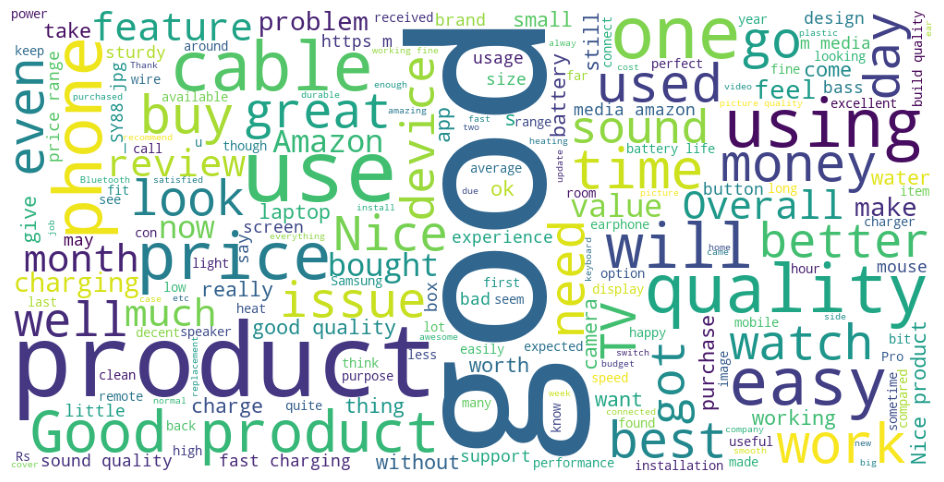

In [72]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [73]:
# Sentiment Analysis
from textblob import TextBlob

df['sentiment_score'] = (
    df['review_content']
    .apply(
        lambda x:
        TextBlob(str(x))
        .sentiment
        .polarity
    )
)
def sentiment(score):

    if score > 0:
        return 'Positive'

    elif score < 0:
        return 'Negative'

    else:
        return 'Neutral'
df['sentiment'] = (
    df['sentiment_score']
    .apply(sentiment)
)
df['sentiment'].value_counts()

sentiment
Positive    1436
Negative      26
Neutral        1
Name: count, dtype: int64

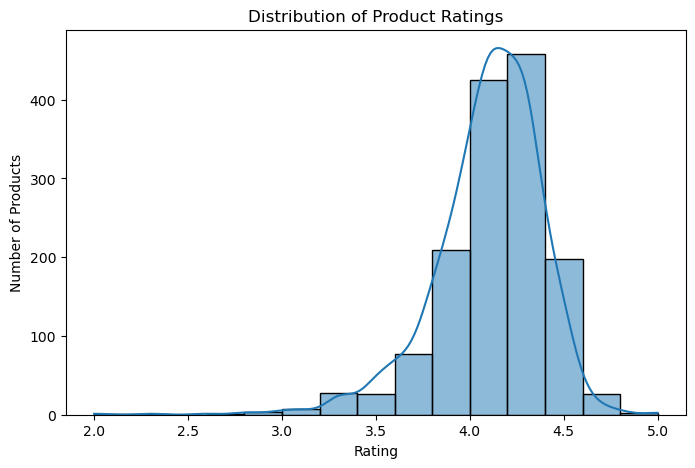

In [74]:
# Business insights
# Are Most Products Highly Rated?
plt.figure(figsize=(8,5))

sns.histplot(
    df['rating'],
    bins=15,
    kde=True
)

plt.xlabel('Rating')
plt.ylabel('Number of Products')
plt.title('Distribution of Product Ratings')

plt.show()
# If most ratings cluster around 4–4.5: Most products are highly rated, indicating strong customer 
# satisfaction across the dataset.

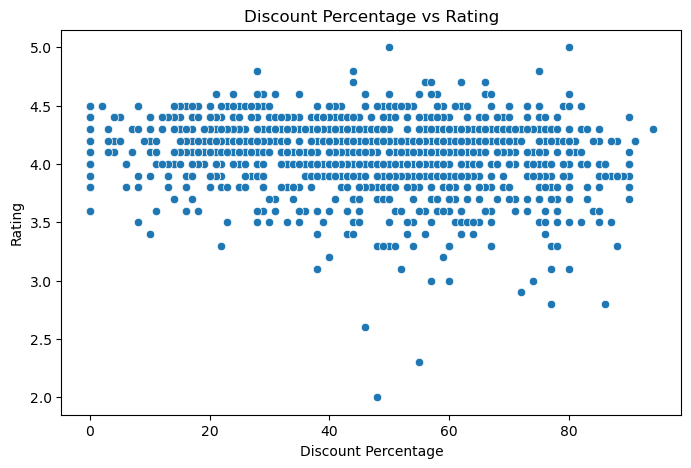

In [75]:
# Larger Discounts Do Not Necessarily Lead to Higher Ratings
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='discount_percentage_numeric',
    y='rating'
)

plt.xlabel('Discount Percentage')
plt.ylabel('Rating')
plt.title('Discount Percentage vs Rating')

plt.show()
# If the dots are scattered randomly: Higher discounts do not necessarily translate into better customer 
# ratings.

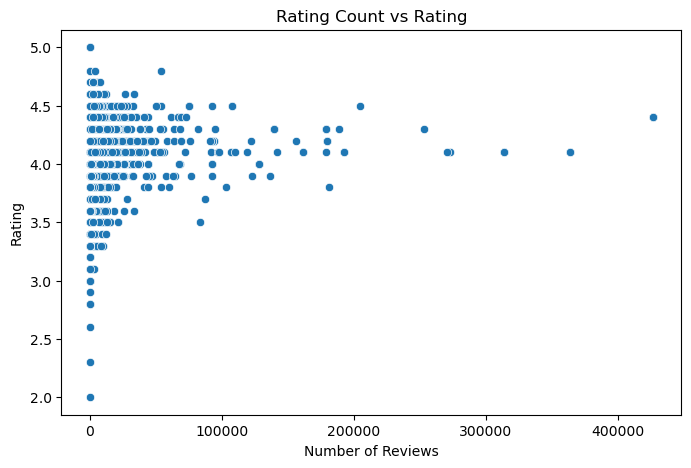

In [76]:
# Popular Products Tend to Have Better Ratings

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='rating_count',
    y='rating'
)

plt.xlabel('Number of Reviews')
plt.ylabel('Rating')
plt.title('Rating Count vs Rating')

plt.show()

# If you see a slight upward trend: Products with greater customer engagement tend to maintain higher ratings.

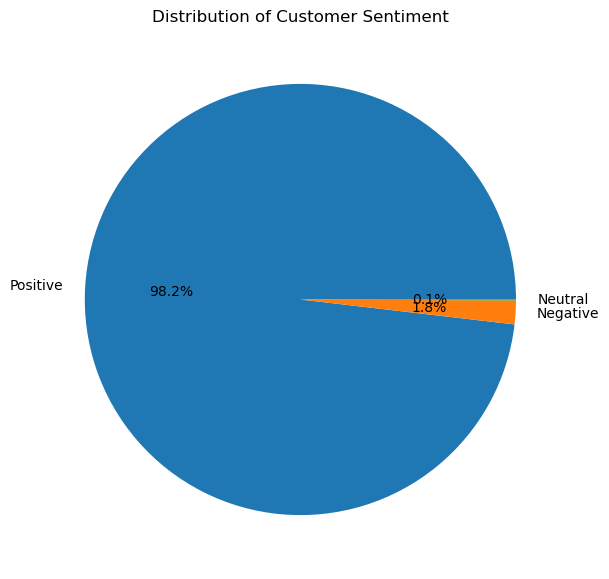

In [77]:
# Most Customer Reviews Express Positive Sentiment

df['sentiment'].value_counts()
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Customer Sentiment')

plt.show()

# Sentiment analysis reveals that the majority of customer reviews are positive, suggesting high overall 
# customer satisfaction.


In [78]:
pd.set_option('display.max_colwidth', 20)  # Limit column widht, show only 20 chars per cell
pd.set_option('display.max_rows', 10)   # only 10 rows
pd.set_option('display.max_columns', 10)  # only 10 columns
df.head(10)

,product_id,product_name,category,discounted_price,actual_price,...,z_log_price,review_length,review_word_count,sentiment_score,sentiment
0,B07JW9H4J1,Wayona Nylon Bra...,Computers&Access...,₹399,1099.0,...,-0.454406,483,60,0.481944,Positive
1,B098NS6PVG,Ambrane Unbreaka...,Computers&Access...,₹199,349.0,...,-1.315618,1186,201,0.274318,Positive
2,B096MSW6CT,Sounce Fast Phon...,Computers&Access...,₹199,1899.0,...,-0.043371,271,13,0.600000,Positive
3,B08HDJ86NZ,boAt Deuce USB 3...,Computers&Access...,₹329,699.0,...,-0.794327,443,77,0.240370,Positive
4,B08CF3B7N1,Portronics Konne...,Computers&Access...,₹154,399.0,...,-1.215194,2451,415,0.262740,Positive
5,B08Y1TFSP6,pTron Solero TB3...,Computers&Access...,₹149,1000.0,...,-0.525334,250,27,0.486667,Positive
6,B08WRWPM22,boAt Micro USB 5...,Computers&Access...,₹176.63,499.0,...,-1.047376,594,120,0.677778,Positive
7,B08DDRGWTJ,MI Usb Type-C Ca...,Computers&Access...,₹229,299.0,...,-1.431549,758,134,0.376042,Positive
8,B008IFXQFU,TP-Link USB WiFi...,Computers&Access...,₹499,999.0,...,-0.526085,3989,678,0.278941,Positive
9,B082LZGK39,Ambrane Unbreaka...,Computers&Access...,₹199,299.0,...,-1.431549,1186,201,0.274318,Positive


In [79]:
df.shape

(1463, 28)